# Séance 4 — Transformation et encodage

**Durée pratique : 3 h** &nbsp;·&nbsp; Ateliers 4.1 à 4.4

## Ce que vous saurez faire à la fin

- mettre une variable à l'échelle, et expliquer ce que l'opération change et ne change pas ;
- reconnaître une fuite de données et l'éviter ;
- encoder des variables catégorielles sans faire exploser le nombre de colonnes ;
- rassembler vos transformations dans une fonction réutilisable.

> **Tout se fait avec pandas et NumPy**, que vous pratiquez depuis deux jours. Aucune
> bibliothèque nouvelle n'est nécessaire pour les exercices. scikit-learn apparaît une
> seule fois, en fin de séance, pour vous montrer qu'il fait en une ligne ce que vous
> aurez écrit à la main — et que vous saurez donc lire.

> **La faute à ne pas commettre.** Calculer une moyenne, un minimum ou une fréquence sur
> l'ensemble des données avant de les séparer en entraînement et test revient à laisser
> filtrer de l'information du test vers l'entraînement. On appelle cela une *fuite de
> données*, et c'est l'erreur la plus courante en préparation de données.

> **Convention de nommage du module.** Le code est écrit en anglais et suit la PEP 8 :
> fonctions et variables en `snake_case`, constantes en `MAJUSCULES`. Les **noms de colonnes**
> restent en français parce qu'ils viennent de la source : renommer les colonnes d'un fichier
> d'entrée est une transformation comme une autre, elle se décide et se documente, elle ne se
> fait pas par réflexe. Vous rencontrerez cette situation partout en entreprise.

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

print('Données disponibles :')
for path in sorted(RAW_DIR.glob('*')):
    print(' ', path.name)


# Parquet conserve les types (dates, entiers, catégories) là où le CSV les perd :
# c'est le format à privilégier entre deux étapes d'un pipeline. Repli automatique
# sur le CSV si pyarrow n'est pas installé.
def save_dataset(df, name):
    try:
        path = PROCESSED_DIR / f'{name}.parquet'
        df.to_parquet(path, index=False)
    except ImportError:
        path = PROCESSED_DIR / f'{name}.csv'
        df.to_csv(path, index=False)
        print('(pyarrow absent : repli sur le CSV)')
    print('écrit :', path.name, df.shape)
    return path


def load_dataset(name):
    parquet_path = PROCESSED_DIR / f'{name}.parquet'
    csv_path = PROCESSED_DIR / f'{name}.csv'
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'{name} introuvable : exécutez le notebook précédent')


def dataset_exists(name):
    return ((PROCESSED_DIR / f'{name}.parquet').exists()
            or (PROCESSED_DIR / f'{name}.csv').exists())

Données disponibles :
  .gitkeep
  capteurs.csv
  clients.csv
  magasins.csv
  produits.csv
  ventes_brutes.csv
  ventes_extrait.json
  ventes_extrait.xlsx


In [6]:
# Reprise du résultat de la séance 3. Si le fichier n'existe pas, relancez le notebook 03.
if dataset_exists('ventes_nettoyees'):
    sales = load_dataset('ventes_nettoyees')
else:
    print('Fichier absent : repli sur un nettoyage minimal.')
    sales = pd.read_csv(RAW_DIR / 'ventes_brutes.csv')
    sales['prix_unitaire'] = pd.to_numeric(
        sales['prix_unitaire'].astype(str)
        .str.replace(' EUR', '', regex=False)
        .str.replace(',', '.', regex=False).str.strip(), errors='coerce')
    sales['date_commande'] = pd.to_datetime(sales['date_commande'],
                                            format='mixed', dayfirst=True, errors='coerce')
    sales = sales.drop_duplicates().dropna(subset=['date_commande'])
    # On ne normalise que les colonnes descriptives : mettre les identifiants
    # en minuscules casserait les jointures de la séance 6 (voir notebook 03).
    for column in ['canal', 'statut', 'ville_livraison']:
        sales[column] = sales[column].str.strip().str.lower()
    sales['montant'] = sales['quantite'] * sales['prix_unitaire']

print(sales.shape)
sales.head(3)

Fichier absent : repli sur un nettoyage minimal.
(17022, 12)


,id_commande,date_commande,id_client,id_produit,id_magasin,quantite,prix_unitaire,remise_pct,canal,statut,ville_livraison,montant
0,CMD0003112,2024-01-18 19:53:00,C02300,P0009,M05,3,160.66,5.0,telephone,retourne,lille,481.98
1,CMD0000107,2024-01-08 00:00:00,C02791,P0028,M03,2,70.48,NaN,boutique,livre,toulouse,140.96
2,CMD0010050,2023-04-15 00:00:00,990031,P0017,M04,3,691.12,0.0,boutique,livre,marseille,2073.36


---
## Atelier 4.1 — Mettre à l'échelle, à la main (45 min)

### Partie guidée : trois formules, rien de plus

Mettre une variable à l'échelle, c'est lui appliquer `(x - centre) / étendue`. Les trois
méthodes du cours ne diffèrent que par ce qu'elles choisissent comme centre et comme
étendue.

| Méthode | Centre | Étendue |
|---|---|---|
| Min-max | le minimum | max − min |
| Z-score | la moyenne | l'écart type |
| Robuste | la médiane | l'écart interquartile (q75 − q25) |

In [7]:
amount = sales['montant'].dropna()

# Les trois formules, écrites directement. Aucune bibliothèque nouvelle.
minmax = (amount - amount.min()) / (amount.max() - amount.min())
zscore = (amount - amount.mean()) / amount.std()

q25, q75 = amount.quantile([0.25, 0.75])
robuste = (amount - amount.median()) / (q75 - q25)

scaled = pd.DataFrame({'brut': amount, 'minmax': minmax,
                       'zscore': zscore, 'robuste': robuste})
scaled.describe().round(3)

,brut,minmax,zscore,robuste
count,17022.000,17022.000,17022.000,17022.000
mean,2705.130,0.007,0.000,1.217
std,29294.697,0.026,1.000,21.306
min,-4504.600,0.000,-0.246,-4.026
25%,520.118,0.005,-0.075,-0.372
50%,1031.315,0.005,-0.057,-0.000
75%,1895.095,0.006,-0.028,0.628
max,1103954.490,1.000,37.592,802.139


**Lecture du tableau.**

- `minmax` ramène tout dans l'intervalle [0 ; 1], mais une seule valeur extrême suffit à
  comprimer toutes les autres près de zéro.
- `zscore` centre sur 0 avec un écart type de 1 ; l'étendue reste libre.
- `robuste` centre sur la médiane et divise par l'écart interquartile : les valeurs
  extrêmes ne déplacent ni le centre ni l'échelle.

Le choix dépend de ce que vous ferez ensuite des données, pas d'une préférence esthétique.

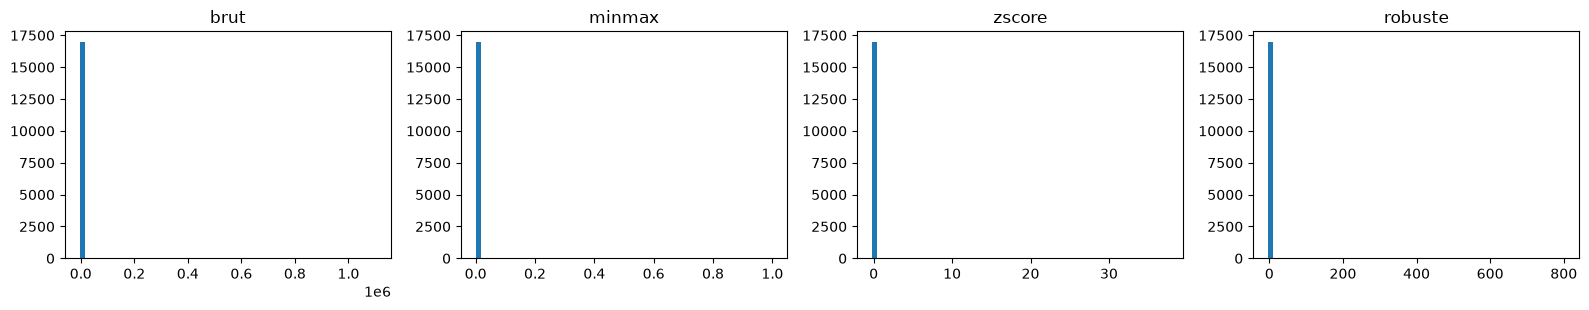

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, column in zip(axes, scaled.columns):
    ax.hist(scaled[column], bins=60)
    ax.set_title(column)
plt.tight_layout()
plt.show()

Les quatre distributions ont **exactement la même forme**. La mise à l'échelle déplace et
étire l'axe ; elle ne corrige ni l'asymétrie ni les valeurs extrêmes. Pour cela, il faut une
transformation non linéaire, par exemple le logarithme.

### Partie autonome

In [ ]:
# Q1. Écrire deux fonctions qui reprennent les formules ci-dessus.
#     Deux lignes chacune. Elles serviront dans tout le reste de la séance.

def scale_minmax(series):
    ...  # TODO


def scale_zscore(series):
    ...  # TODO


assert np.allclose(scale_minmax(amount), minmax)
assert np.allclose(scale_zscore(amount), zscore)
assert round(scale_minmax(amount).min(), 6) == 0
assert round(scale_minmax(amount).max(), 6) == 1
print('OK — les deux fonctions reproduisent les formules guidées')

In [ ]:
# Q2. Ajouter une colonne 'log' contenant log(1 + montant), puis comparer
#     l'asymétrie (.skew()) des cinq colonnes.
#     Indice : np.log1p(x) calcule log(1 + x).
#     Question à traiter en commentaire : pourquoi les trois mises à l'échelle
#     ont-elles toutes la même asymétrie que la colonne brute ?

# TODO

---
## Atelier 4.2 — La fuite de données (25 min)

### Partie guidée

Le principe est simple, et ne demande aucune bibliothèque : on sépare les données en deux,
et **tout ce qu'on calcule doit l'être sur la partie entraînement seulement**. Moyenne,
écart type, minimum, médiane, fréquence d'une modalité : toutes ces quantités s'apprennent
sur l'entraînement, puis s'appliquent au test.

In [9]:
# Séparation en deux, avec pandas : 80 % / 20 %
train = sales.sample(frac=0.8, random_state=0)
test = sales.drop(train.index)

print(f'entraînement {len(train)} lignes | test {len(test)} lignes')
print(f"moyenne apprise sur l'entraînement : {train['montant'].mean():.2f} EUR")
print(f"moyenne de l'ensemble complet      : {sales['montant'].mean():.2f} EUR")

entraînement 13618 lignes | test 3404 lignes
moyenne apprise sur l'entraînement : 2705.06 EUR
moyenne de l'ensemble complet      : 2705.13 EUR


Les deux moyennes sont proches, mais elles ne sont pas égales — et c'est tout le sujet.
Utiliser la seconde pour centrer le test reviendrait à se servir d'une information calculée
en partie sur des lignes qu'on est censé n'avoir jamais vues.

### Partie autonome

In [ ]:
# Q3. Comparer les deux façons de centrer et réduire le jeu de test.
#
#   a) MÉTHODE FAUTIVE : centrer le test avec la moyenne et l'écart type
#      calculés sur `sales` (l'ensemble complet).
#   b) MÉTHODE CORRECTE : les calculer sur `train` uniquement.
#
#   Puis afficher, pour chaque méthode, la moyenne du test transformé.
#   Laquelle est la plus proche de zéro ? Pourquoi est-ce le symptôme du problème ?

# TODO

*Votre réponse en deux phrases :*


---
## Atelier 4.3 — Encoder les variables catégorielles (35 min)

### Partie guidée

Une seule fonction est nécessaire : `pd.get_dummies`, qui crée une colonne binaire par
modalité. C'est ce qu'on appelle l'encodage *one-hot*.

In [10]:
products = pd.read_csv(RAW_DIR / 'produits.csv')
sales_enriched = sales.merge(products, on='id_produit', how='left')

for column in ['canal', 'statut', 'categorie', 'sous_categorie', 'id_magasin']:
    print(f'{column:<16} {sales_enriched[column].nunique():>4} modalités')

canal               3 modalités
statut              3 modalités
categorie           4 modalités
sous_categorie     13 modalités
id_magasin          9 modalités


In [11]:
# One-hot : une colonne binaire par modalité
one_hot = pd.get_dummies(sales_enriched[['canal', 'statut']], prefix_sep='=', dtype=int)
print('Colonnes créées :', one_hot.shape[1])
one_hot.head()

Colonnes créées : 6


,canal=boutique,canal=telephone,canal=web,statut=annule,statut=livre,statut=retourne
0,0,1,0,0,0,1
1,1,0,0,0,1,0
2,1,0,0,0,1,0
3,0,0,1,0,0,1
4,0,0,1,0,1,0


**Trois paramètres à connaître.** `prefix_sep='='` produit des noms lisibles du type
`canal=web`. `dtype=int` donne des 0 et des 1 plutôt que des booléens, plus commodes en
aval. `drop_first=True`, qu'on ne met pas ici, supprime une modalité par variable : utile
pour les modèles linéaires, inutile pour un export vers un outil de BI où la lisibilité
prime.

In [12]:
# Le problème de la forte cardinalité : regrouper les modalités rares
def group_rare_categories(series, min_frequency=0.01, other_label='autre'):
    frequencies = series.value_counts(normalize=True)
    rare_labels = frequencies[frequencies < min_frequency].index
    return series.where(~series.isin(rare_labels), other_label)


before = sales_enriched['sous_categorie'].nunique()
after = group_rare_categories(sales_enriched['sous_categorie'], min_frequency=0.05).nunique()
print(f'{before} modalités -> {after} après regroupement à 5 %')

13 modalités -> 13 après regroupement à 5 %


### Partie autonome

In [ ]:
# Q4. Encoder le jeu enrichi :
#     - one-hot pour canal, statut et categorie ;
#     - regrouper les modalités sous 2 % de sous_categorie, PUIS l'encoder ;
#     - assembler le tout avec pd.concat et compter les colonnes avant et après.
#
#     Question à traiter en commentaire : y a-t-il, dans ce jeu, une variable
#     réellement ORDONNÉE, qu'on pourrait encoder par des entiers 0, 1, 2 ?
#     Si non, expliquez pourquoi le faire quand même serait une erreur.

# TODO

---
## Atelier 4.4 — Variables dérivées et fonction de préparation (1 h 15)

L'encodage rend les données lisibles par une machine. Les variables dérivées les rendent
**informatives**. C'est la partie du travail où la connaissance du domaine compte davantage
que la technique.

In [13]:
# Exemple guidé : la marge, calculable dès lors que le coût d'achat est connu
sales_enriched['marge_unitaire'] = (sales_enriched['prix_unitaire']
                                    - sales_enriched['cout_achat'])
sales_enriched['taux_marge'] = (sales_enriched['marge_unitaire']
                                / sales_enriched['prix_unitaire']).round(4)

print(sales_enriched[['prix_unitaire', 'cout_achat',
                      'marge_unitaire', 'taux_marge']].describe().round(2))

       prix_unitaire  cout_achat  marge_unitaire  taux_marge
count       17022.00    16517.00        16517.00    16517.00
mean          617.15      325.24          305.44        0.48
std           344.20      173.19          167.54        0.03
min            60.90       34.81           26.09        0.43
25%           279.96      147.07          153.52        0.46
50%           583.67      295.37          299.49        0.48
75%           926.06      481.66          446.23        0.51
max          1287.23      605.08          682.15        0.53


Attention au dénominateur : si un prix vaut zéro, le taux devient infini et contaminera
toutes les agrégations en aval. Vérifiez systématiquement les divisions.

In [ ]:
# Q5. Créer quatre variables dérivées à valeur métier. Pour chacune, un commentaire
#     d'une ligne expliquant à quelle question elle permet de répondre.
#     Pistes : montant après remise, panier moyen du client (groupby + transform),
#     indicateur de commande non aboutie, écart au prix médian de la catégorie.
#     Terminez par un contrôle : aucune valeur infinie introduite ?

# TODO

### Rassembler le tout dans une fonction

Vos transformations sont pour l'instant éparpillées dans des cellules. Comme au jour 2 avec
`clean_sales`, on les rassemble dans **une fonction** : c'est ce qui permet de rejouer la
préparation sur de nouvelles données sans rouvrir le notebook.

In [ ]:
# Q6. Écrire prepare_features(df) qui applique, dans l'ordre :
#       1. la jointure avec le référentiel produits ;
#       2. les variables dérivées de la question 5 ;
#       3. l'encodage one-hot de la question 4 ;
#       4. la mise à l'échelle de montant avec scale_zscore.
#     La fonction copie son entrée et renvoie un nouveau DataFrame.

def prepare_features(df, products):
    ...  # TODO


prepared = prepare_features(sales, products)
print('Colonnes en entrée :', sales.shape[1])
print('Colonnes en sortie :', prepared.shape[1])

In [ ]:
# Export du jeu transformé, pour les séances 5, 6 et 8.

save_dataset(sales_enriched, 'ventes_transformees')

---
## Pour aller plus loin — ce que scikit-learn fait à votre place (démonstration)

**Cette partie n'est pas un exercice.** Exécutez-la et lisez-la : elle montre que la
bibliothèque scikit-learn fait exactement ce que vous venez d'écrire, en une ligne. Vous
l'utiliserez dans les modules de modélisation ; ici, l'objectif est seulement que le code
ne vous soit pas étranger quand vous le rencontrerez.

In [14]:
from sklearn.preprocessing import StandardScaler

# Votre fonction de la question 1
a_la_main = scale_zscore(amount)

# La même chose avec scikit-learn
scaler = StandardScaler()
par_sklearn = scaler.fit_transform(amount.to_frame()).ravel()

comparaison = pd.DataFrame({'a_la_main': a_la_main.values[:5],
                            'par_sklearn': par_sklearn[:5]}).round(6)
print(comparaison.to_string(index=False))
print()
print('Écart maximal entre les deux :',
      float(np.abs(a_la_main.values - par_sklearn).max()).__round__(6))

NameError: name 'scale_zscore' is not defined

**Les valeurs coïncident jusqu'au cinquième chiffre.** Le petit écart résiduel vient du
dénominateur : pandas divise par l'écart type corrigé (`ddof=1`), scikit-learn par l'écart
type non corrigé (`ddof=0`). Le rapport entre les deux vaut environ 1 + 1/(2n), soit trois
cent-millièmes sur 17 000 lignes. L'écart maximal affiché porte donc sur la valeur la plus
extrême du jeu, la seule assez grande pour que ce rapport devienne visible. Sur dix lignes,
l'écart ne serait plus négligeable du tout.

**Le vocabulaire de scikit-learn tient en deux mots.** `fit` apprend les paramètres — ici la
moyenne et l'écart type. `transform` les applique. `fit_transform` fait les deux d'un coup,
et ne doit donc **jamais** être appelé sur le jeu de test : ce serait exactement la fuite de
l'atelier 4.2.

```python
scaler.fit(X_train)            # apprend sur l'entraînement
X_test_scaled = scaler.transform(X_test)    # applique au test
```

Le reste de la bibliothèque — `OneHotEncoder`, `SimpleImputer`, `ColumnTransformer`,
`Pipeline` — suit exactement la même logique, appliquée à d'autres transformations. Rien de
plus à retenir aujourd'hui.

---
## Livrable de la séance

- `src/transformation.py` contenant `scale_minmax`, `scale_zscore` et `prepare_features` ;
- `data/processed/ventes_transformees.parquet` ;
- les quatre variables dérivées, chacune accompagnée de sa justification métier ;
- votre réponse écrite sur la fuite de données (question 3).